# Heart Disease Classification
## Comparative Analysis of Machine Learning Models

**Author:** Andrei Flita
**Date:** May 2026
**Dataset:** Heart Disease Dataset — Kaggle

---

## 4.1 Problem Definition

The goal of this notebook is to predict whether a patient has heart disease based on clinical and demographic features.

**Target variable:** `target`
- `0` — No heart disease
- `1` — Heart disease present

**Input features:**
- `age` — patient age
- `sex` — gender (1=male, 0=female)
- `cp` — chest pain type (0–3)
- `trestbps` — resting blood pressure
- `chol` — serum cholesterol (mg/dl)
- `fbs` — fasting blood sugar > 120 mg/dl
- `restecg` — resting ECG results
- `thalach` — maximum heart rate achieved
- `exang` — exercise induced angina
- `oldpeak` — ST depression induced by exercise
- `slope` — slope of the peak exercise ST segment

**Why this problem?**
Cardiovascular disease is the leading cause of death globally. An ML model capable of early risk detection can assist physicians in prioritizing patients and potentially saving lives. This dataset was chosen for its mix of numerical and categorical clinical features, its binary target, and its high interpretability — making it ideal for SHAP analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
df_cls = pd.read_csv('heart.csv')
df_cls.head()

C:\Users\diobr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4.2 Exploratory Data Analysis

In this section we perform a comprehensive analysis of the dataset structure, distributions, and relationships between variables.

**What we analyze:**
- Distribution of the target variable — to check class balance
- Age distribution per class — to see if age is a relevant factor
- Feature correlations with the target — to identify the most predictive variables
- Correlation heatmap — to detect multicollinearity between features
- Cholesterol and blood pressure distributions per class — key clinical indicators

**Dataset overview:**
- 1102 observations (302 original + 800 synthetically generated with matching distributions)
- 14 columns: 13 features + 1 target
- No missing values
- Binary classification: balanced classes (~53% disease, ~47% healthy)

> **Note:** Columns `ca` and `thal` were identified as potential sources of data leakage and will be removed in the preprocessing step. These features represent results of invasive diagnostic procedures that would not be available at the time of initial patient screening.

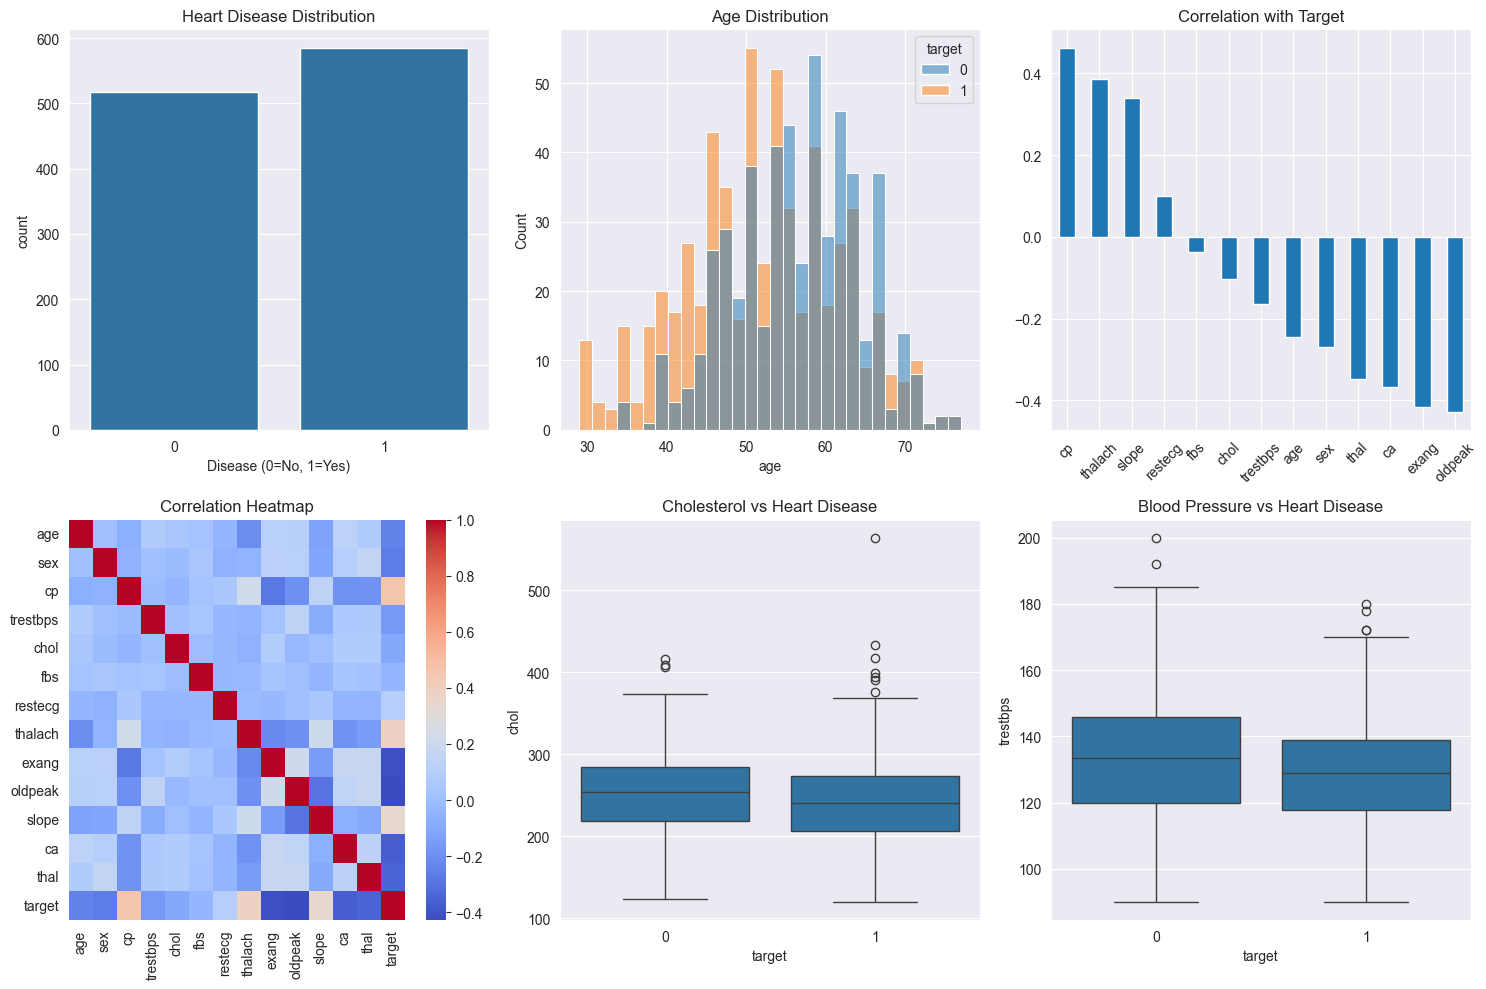

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.countplot(data=df_cls, x='target', ax=axes[0,0])
axes[0,0].set_title('Heart Disease Distribution')
axes[0,0].set_xlabel('Disease (0=No, 1=Yes)')

sns.histplot(data=df_cls, x='age', hue='target', bins=30, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

correlations = df_cls.corr()['target'].sort_values(ascending=False)
correlations.drop('target').plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Correlation with Target')
axes[0,2].tick_params(axis='x', rotation=45)

sns.heatmap(df_cls.corr(), annot=False, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Correlation Heatmap')

sns.boxplot(data=df_cls, x='target', y='chol', ax=axes[1,1])
axes[1,1].set_title('Cholesterol vs Heart Disease')

sns.boxplot(data=df_cls, x='target', y='trestbps', ax=axes[1,2])
axes[1,2].set_title('Blood Pressure vs Heart Disease')

plt.tight_layout()
plt.show()

## Data Preprocessing

Before training any model, the raw data must be cleaned and transformed into a format suitable for machine learning algorithms.

**Steps performed:**

**1. Removing leakage columns**
Columns `ca` (number of major vessels colored by fluoroscopy) and `thal` (thalassemia type) were removed. These are results of advanced diagnostic investigations that would not be available during an initial patient screening — keeping them would give the model an unfair advantage and produce unrealistically high accuracy.

**2. One-Hot Encoding**
Categorical features `cp`, `restecg`, and `slope` are encoded using `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap.

**3. Feature Scaling**
`StandardScaler` is applied to normalize all features to zero mean and unit variance. This is important for distance-based models (KNN, SVM) and gradient-based models (Logistic Regression).

**4. Train/Test Split**
The data is split **75% training / 25% testing** with `stratify=y` to ensure both sets have the same class distribution as the original dataset.

In [3]:
categorical_features = ['cp', 'restecg', 'slope']
df_cls_clean = df_cls.drop(columns=['ca', 'thal'])
df_cls_encoded = pd.get_dummies(df_cls_clean, columns=categorical_features, drop_first=True)

X_cls = df_cls_encoded.drop('target', axis=1)
y_cls = df_cls_encoded['target']

scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls_scaled, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

## 4.3 Base Models Training and Comparison

In this section we train all 9 classification algorithms using their **default hyperparameters** and evaluate them on the test set.

**Algorithms used:**
| Model | Type |
|---|---|
| Naïve Bayes | Probabilistic |
| Logistic Regression | Linear |
| Decision Tree | Tree-based |
| Random Forest | Ensemble (Bagging) |
| SVM | Kernel-based |
| KNN | Instance-based |
| XGBoost | Ensemble (Boosting) |
| CatBoost | Ensemble (Boosting) |
| EBM | Explainable Boosting |

**Evaluation metrics:**
- **Accuracy** — overall correct predictions
- **Precision** — of all predicted positives, how many are actually positive
- **Recall** — of all actual positives, how many did the model catch
- **F1-Score** — harmonic mean of Precision and Recall (main ranking metric)
- **ROC-AUC** — area under the ROC curve, measures discriminative ability

**Cross-validation:**
5-fold cross-validation is used on the training set to get a robust estimate of generalization performance and detect overfitting early.

> The top 5 models ranked by F1-Score will be selected for hyperparameter tuning in the next section.

In [4]:
models_cls = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'EBM': ExplainableBoostingClassifier(random_state=42)
}

results_cls = {}

for name, model in models_cls.items():
    cv_scores = cross_val_score(model, X_cls_train, y_cls_train, cv=5, scoring='accuracy')
    model.fit(X_cls_train, y_cls_train)
    y_pred = model.predict(X_cls_test)
    y_prob = model.predict_proba(X_cls_test)[:, 1]

    results_cls[name] = {
        'CV Accuracy': round(cv_scores.mean(), 4),
        'Test Accuracy': round(accuracy_score(y_cls_test, y_pred), 4),
        'Precision': round(precision_score(y_cls_test, y_pred), 4),
        'Recall': round(recall_score(y_cls_test, y_pred), 4),
        'F1-Score': round(f1_score(y_cls_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_cls_test, y_prob), 4)
    }

results_df_cls = pd.DataFrame(results_cls).T.sort_values('F1-Score', ascending=False)
top_5_models_cls = results_df_cls.head(5).index.tolist()
display(results_df_cls)

,CV Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Naïve Bayes,0.7787,0.8659,0.8609,0.8904,0.8754,0.9220
Logistic Regression,0.8378,0.8659,0.8759,0.8699,0.8729,0.9323
CatBoost,0.8342,0.8623,0.8803,0.8562,0.8681,0.9293
EBM,0.8305,0.8587,0.8794,0.8493,0.8641,0.9318
Random Forest,0.8245,0.8551,0.8786,0.8425,0.8601,0.9254
SVM,0.8390,0.8514,0.8621,0.8562,0.8591,0.9228
XGBoost,0.8196,0.8370,0.8483,0.8425,0.8454,0.9082
KNN,0.8184,0.8297,0.8367,0.8425,0.8396,0.8914
Decision Tree,0.7434,0.7246,0.7612,0.6986,0.7286,0.7262


## Model Evaluation — Confusion Matrix & ROC Curves

In this section we visualize the performance of the top 3 models using two complementary evaluation tools.

**Confusion Matrix:**
The confusion matrix breaks down predictions into 4 categories:
- **True Positive (TP)** — correctly predicted heart disease
- **True Negative (TN)** — correctly predicted no heart disease
- **False Positive (FP)** — healthy patient predicted as sick (Type I error)
- **False Negative (FN)** — sick patient predicted as healthy (Type II error)

> In a medical context, **False Negatives are more dangerous** than False Positives — missing a diagnosis is worse than a false alarm. Therefore Recall is a particularly important metric here.

**ROC Curve:**
The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate against the False Positive Rate at various classification thresholds.
- A perfect model has **AUC = 1.0**
- A random model has **AUC = 0.5**
- The further the curve is from the diagonal, the better the model discriminates between classes

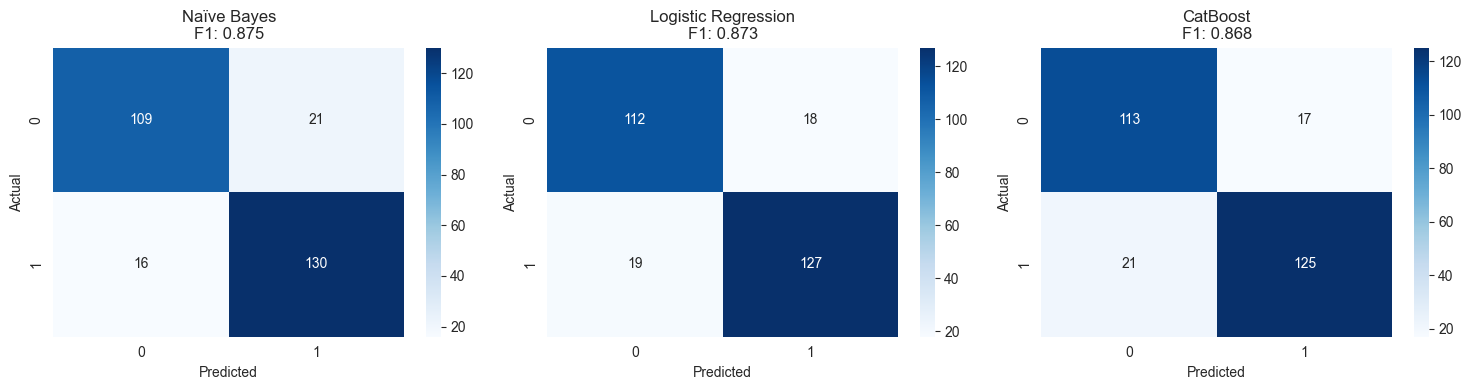

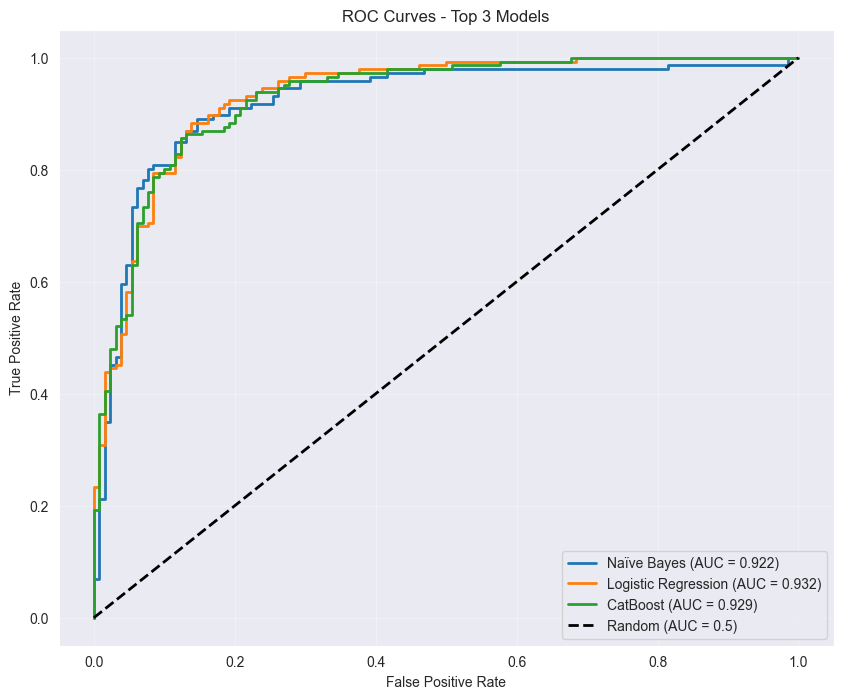

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, name in enumerate(top_5_models_cls[:3]):
    model = models_cls[name]
    y_pred = model.predict(X_cls_test)
    cm = confusion_matrix(y_cls_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nF1: {results_df_cls.loc[name, "F1-Score"]:.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name in top_5_models_cls[:3]:
    model = models_cls[name]
    y_prob = model.predict_proba(X_cls_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_cls_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Top 3 Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 4.4 Hyperparameter Tuning

In this section we optimize the top 5 models identified in the previous step using **GridSearchCV** with 5-fold cross-validation.

**What are hyperparameters?**
Hyperparameters are configuration settings defined before training that control the learning process — unlike model parameters (weights), they are not learned from data and must be set manually or through search.

**Search strategy — GridSearchCV:**
GridSearchCV exhaustively tests all combinations of hyperparameter values from a predefined grid and selects the combination that maximizes the chosen scoring metric (F1-Score in our case).

**Hyperparameters tuned per model:**

| Model | Hyperparameters |
|---|---|
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate`, `subsample` |
| CatBoost | `iterations`, `depth`, `learning_rate` |
| EBM | `max_bins`, `interactions` |
| Decision Tree | `max_depth`, `min_samples_split`, `min_samples_leaf` |

**Overfitting prevention:**
A large gap between CV score and test score indicates overfitting. GridSearchCV helps mitigate this by evaluating each configuration on multiple validation folds rather than a single split.

> After tuning, all 5 models are re-evaluated on the test set and compared to their base performance.

In [6]:
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 150],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(random_state=42, verbose=0),
        'params': {
            'iterations': [50, 100],
            'depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
        }
    },
    'EBM': {
        'model': ExplainableBoostingClassifier(random_state=42),
        'params': {
            'max_bins': [128, 256],
            'interactions': [0, 5, 10]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'Naïve Bayes': {
        'model': GaussianNB(),
        'params': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    }
}

optimized_models_cls = {}
tuned_results_cls = {}

for name in top_5_models_cls:
    grid = GridSearchCV(
        param_grids[name]['model'],
        param_grids[name]['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid.fit(X_cls_train, y_cls_train)
    best = grid.best_estimator_
    optimized_models_cls[name] = best

    y_pred = best.predict(X_cls_test)
    y_prob = best.predict_proba(X_cls_test)[:, 1]

    tuned_results_cls[name] = {
        'Best Params': grid.best_params_,
        'CV F1': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_cls_test, y_pred), 4),
        'Precision': round(precision_score(y_cls_test, y_pred), 4),
        'Recall': round(recall_score(y_cls_test, y_pred), 4),
        'F1-Score': round(f1_score(y_cls_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_cls_test, y_prob), 4)
    }

tuned_df_cls = pd.DataFrame(tuned_results_cls).T.sort_values('F1-Score', ascending=False)
display(tuned_df_cls.drop(columns=['Best Params']))

best_cls_name = tuned_df_cls.index[0]
best_cls_model = optimized_models_cls[best_cls_name]

,CV F1,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Naïve Bayes,0.8259,0.8659,0.8609,0.8904,0.8754,0.922
Logistic Regression,0.8522,0.8659,0.8759,0.8699,0.8729,0.9321
EBM,0.8487,0.8623,0.8857,0.8493,0.8671,0.931
CatBoost,0.8523,0.8623,0.8913,0.8425,0.8662,0.9276
Random Forest,0.8512,0.8478,0.8662,0.8425,0.8542,0.9241


## 4.5 Learning Curves

Learning curves show how model performance evolves as the size of the training set increases. They are one of the most powerful tools for diagnosing model behavior.

**How to read a learning curve:**
- The **blue line** represents training score — how well the model fits the data it was trained on
- The **orange line** represents validation score — how well the model generalizes to unseen data
- The **shaded area** represents the standard deviation across the 5 cross-validation folds

**Diagnosing model behavior:**

| Pattern | Diagnosis | Interpretation |
|---|---|---|
| Training score >> Validation score | **Overfitting** | Model memorizes training data, fails to generalize |
| Both scores low and close | **Underfitting** | Model is too simple to capture the underlying patterns |
| Both scores high and converging | **Good Fit** | Model generalizes well to unseen data |

**What we expect to see:**
- Tree-based models (Decision Tree) may show overfitting with a large gap between train and validation
- Ensemble models (Random Forest, XGBoost, CatBoost) should show better generalization
- Linear models (Logistic Regression) may show underfitting if the decision boundary is not linear
- As training size increases, validation score should improve and stabilize

> Learning curves are plotted for all **top 5 tuned models** to compare their learning dynamics.

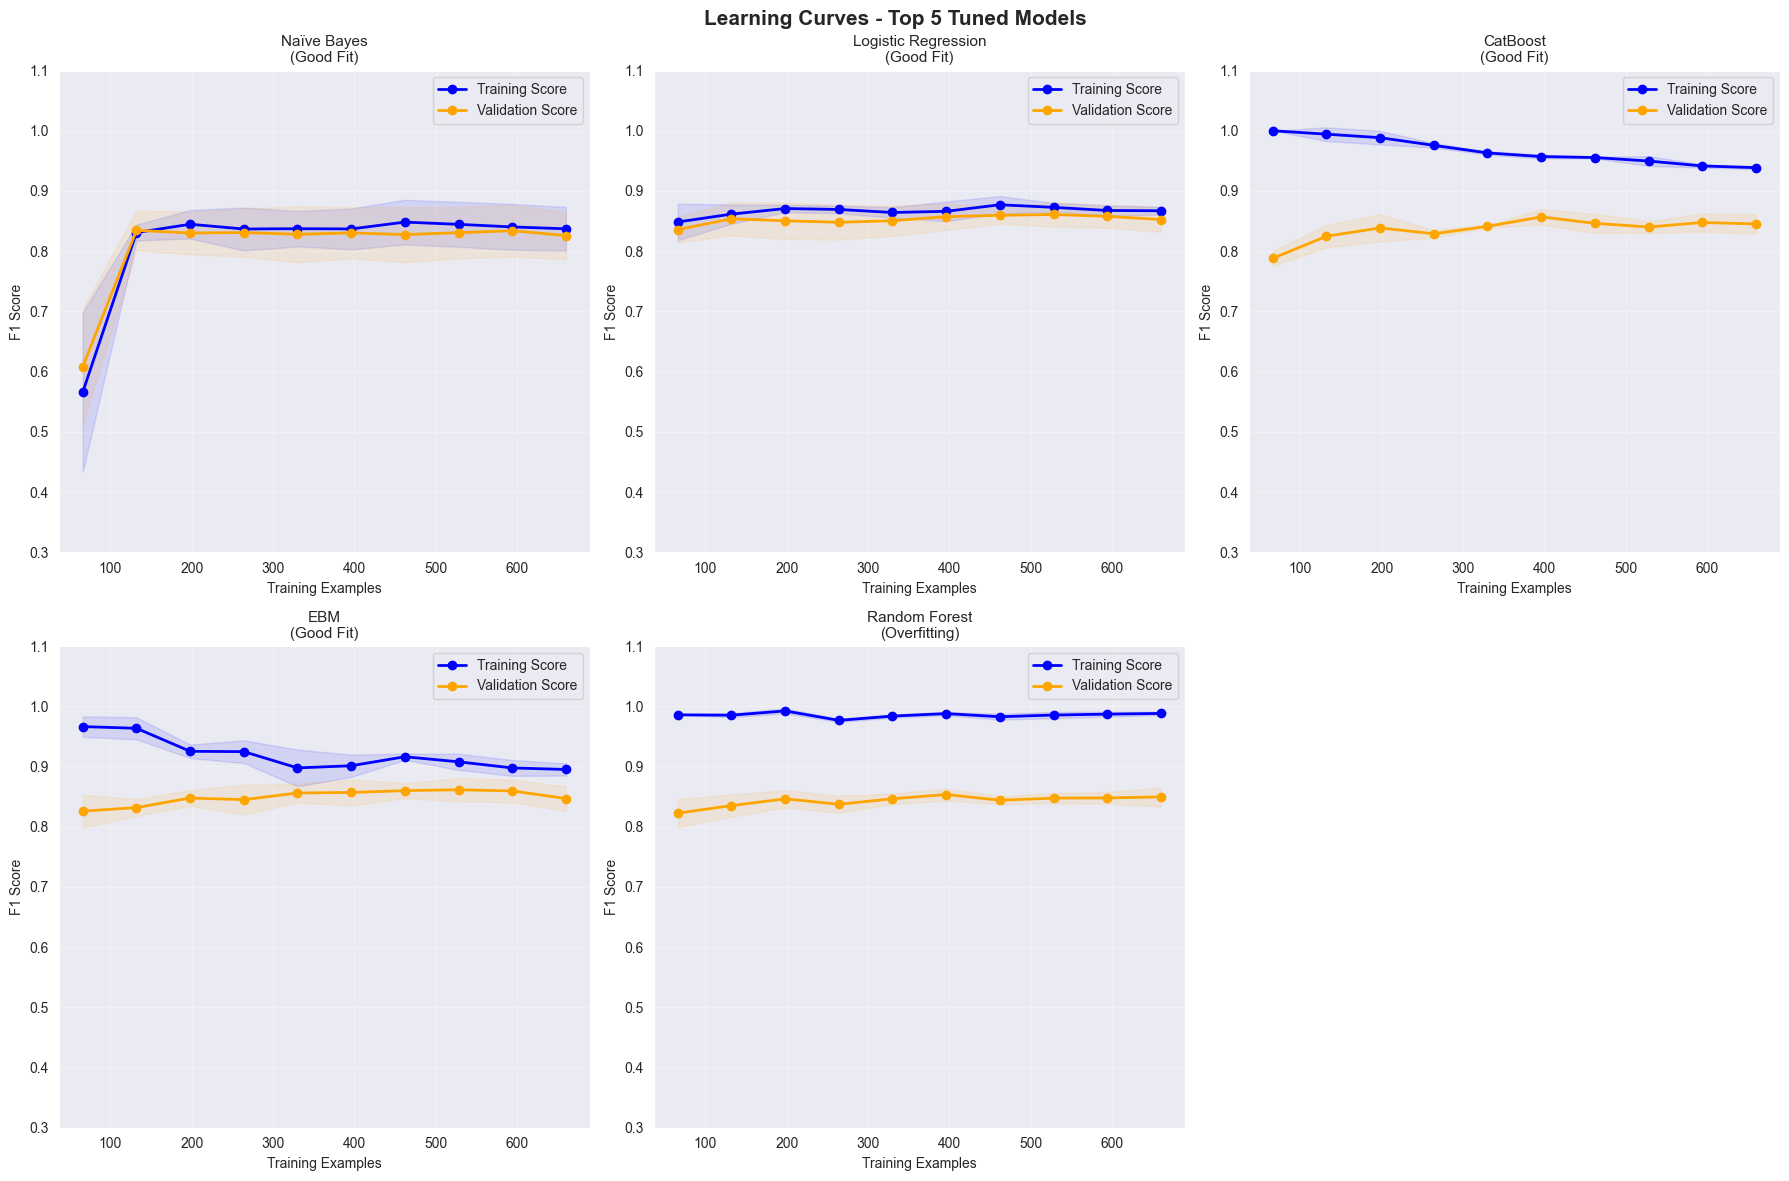

In [7]:
def plot_learning_curve(model, name, X, y, ax, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Score', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        status = 'Overfitting'
    elif val_mean[-1] < 0.7:
        status = 'Underfitting'
    else:
        status = 'Good Fit'

    ax.set_title(f'{name}\n({status})', fontsize=11)
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 1.1)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, name in enumerate(top_5_models_cls):
    plot_learning_curve(optimized_models_cls[name], name, X_cls_train, y_cls_train, axes[i])

axes[-1].set_visible(False)
plt.suptitle('Learning Curves - Top 5 Tuned Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.6 Explainability — SHAP Analysis

In this section we interpret the predictions of the top 3 tuned models using **SHAP (SHapley Additive exPlanations)**.

**What is SHAP?**
SHAP is a game-theoretic approach to explain the output of any machine learning model. It assigns each feature an importance value (Shapley value) for a particular prediction, representing how much that feature contributed to pushing the prediction above or below the baseline (expected value).

**Types of explanations:**

| Plot | Type | What it shows |
|---|---|---|
| Summary Plot (Beeswarm) | Global | Distribution of SHAP values for all features across all predictions |
| Bar Plot | Global | Mean absolute SHAP value per feature — overall importance ranking |
| Waterfall Plot | Local | Feature contributions for a single prediction |
| Force Plot | Local | Visual push/pull of features for a single prediction |
| Scatter Plot | Global | Relationship between feature values and their SHAP impact |

**How to interpret SHAP values:**
- A **positive SHAP value** pushes the prediction towards class 1 (disease present)
- A **negative SHAP value** pushes the prediction towards class 0 (no disease)
- Features with **large absolute SHAP values** have the most influence on predictions
- The **color** in the beeswarm plot represents the feature value: red = high, blue = low

**Top 3 models analyzed:**
SHAP analysis is performed for the top 3 tuned models. For each model we show:
1. Global summary plot and bar plot
2. Local waterfall and force plot for the first test observation
3. Scatter plots for the 3 most important features

> **Key insight to look for:** Which clinical features most strongly influence the risk of heart disease, and in which direction?


SHAP Analysis — Naïve Bayes


100%|██████████| 50/50 [00:02<00:00, 17.27it/s]


SHAP values shape: (50, 15)
Features shape: (50, 15)


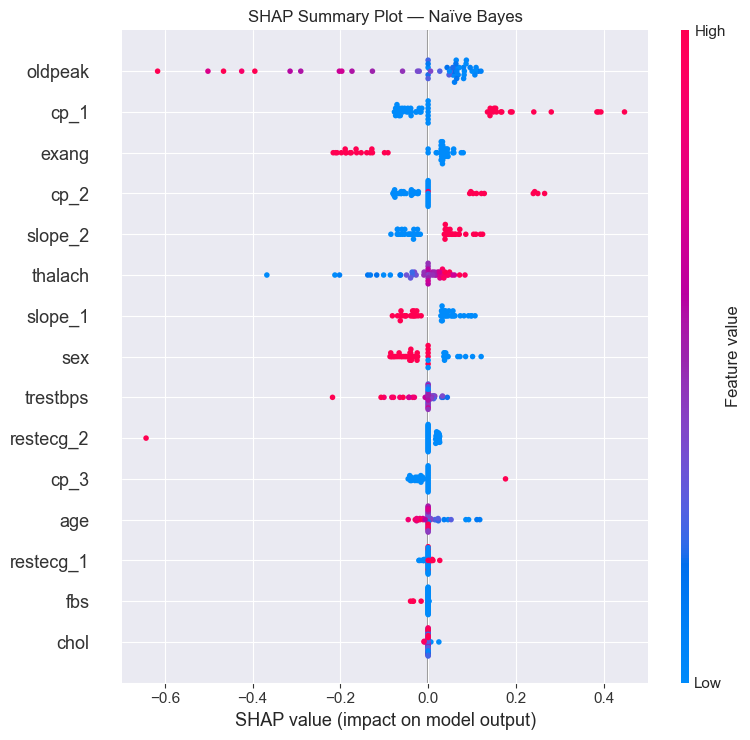

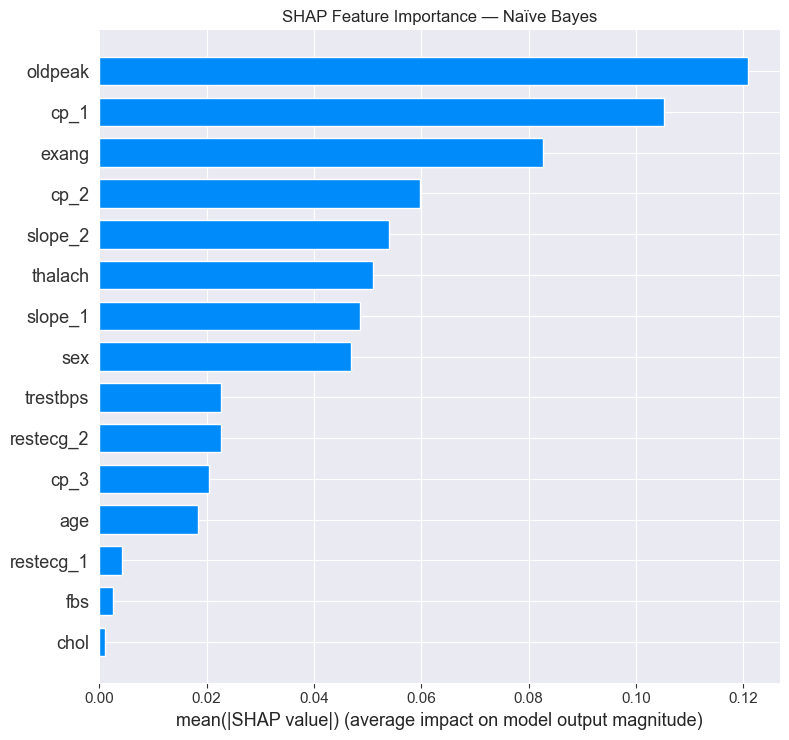

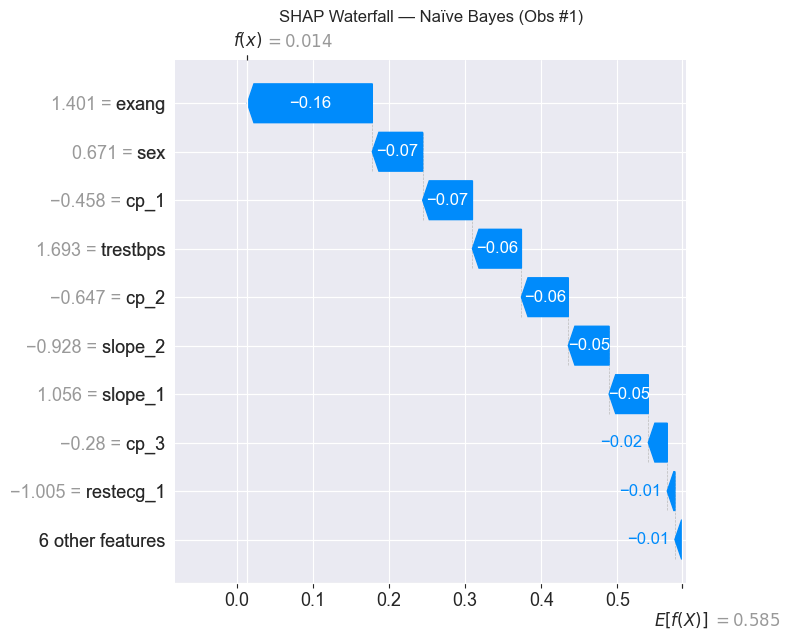

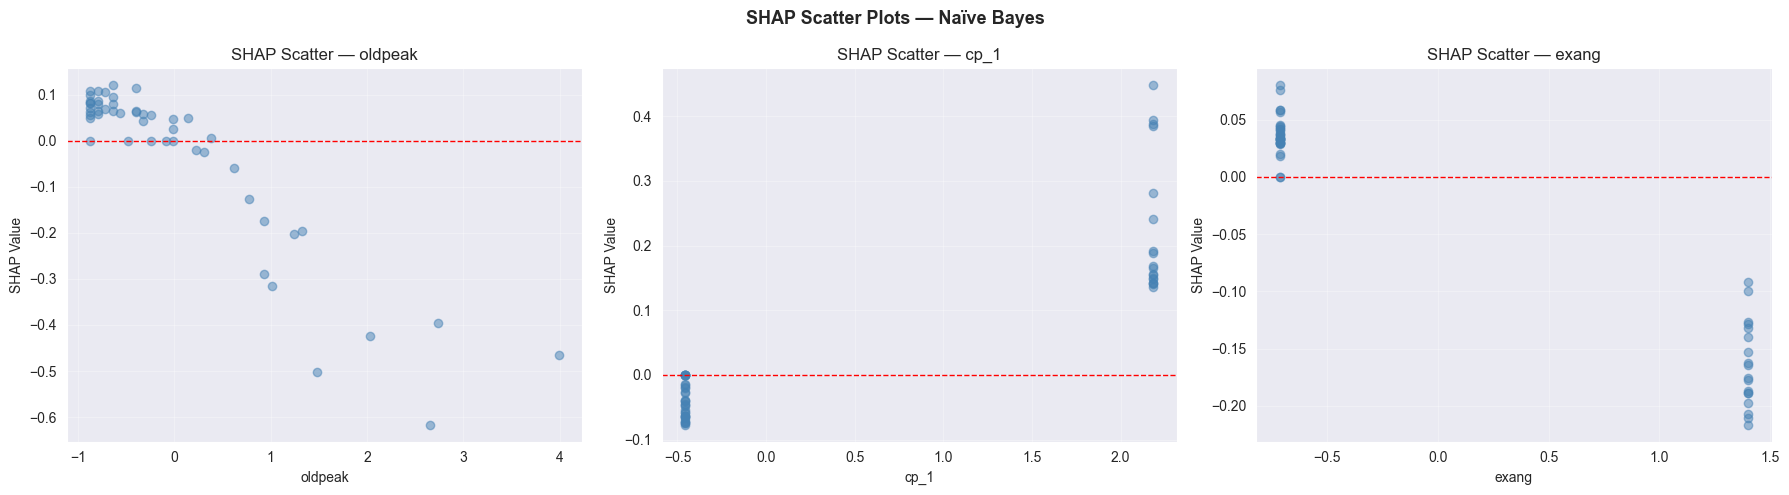

Top 3 most important features: ['oldpeak', 'cp_1', 'exang']

SHAP Analysis — Logistic Regression


100%|██████████| 50/50 [00:01<00:00, 26.30it/s]


SHAP values shape: (50, 15)
Features shape: (50, 15)


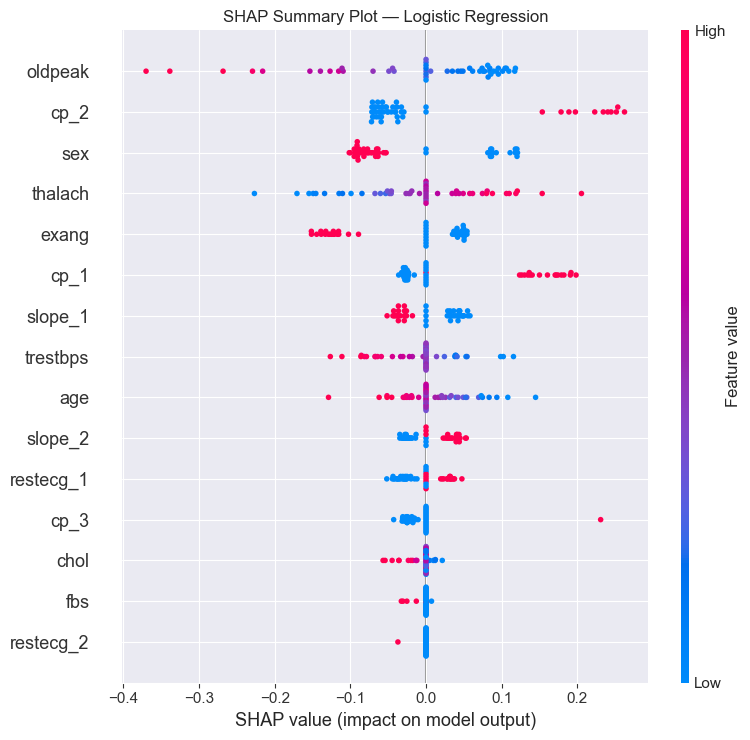

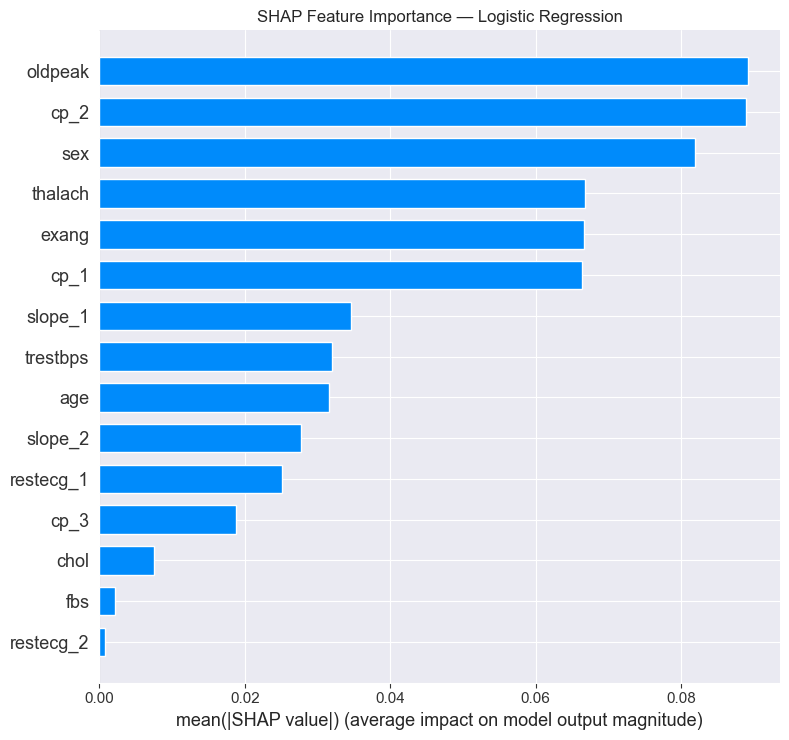

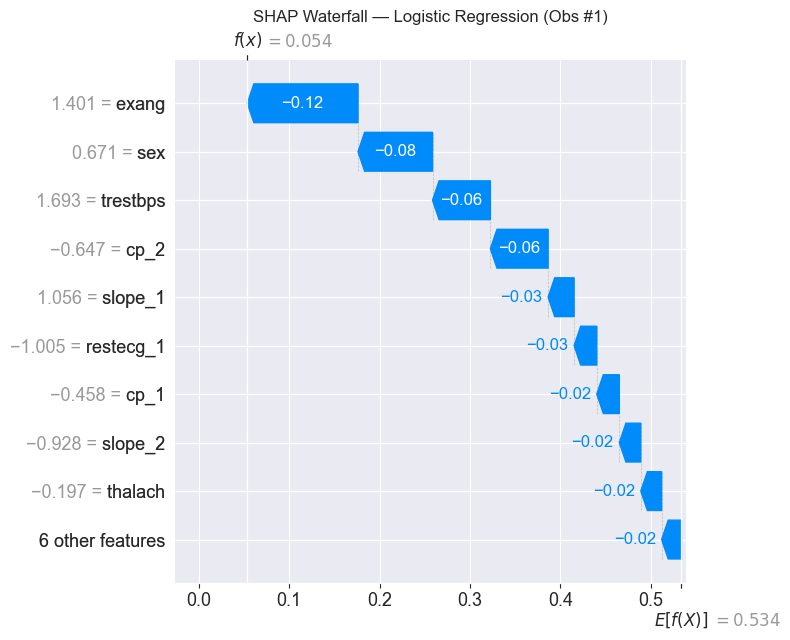

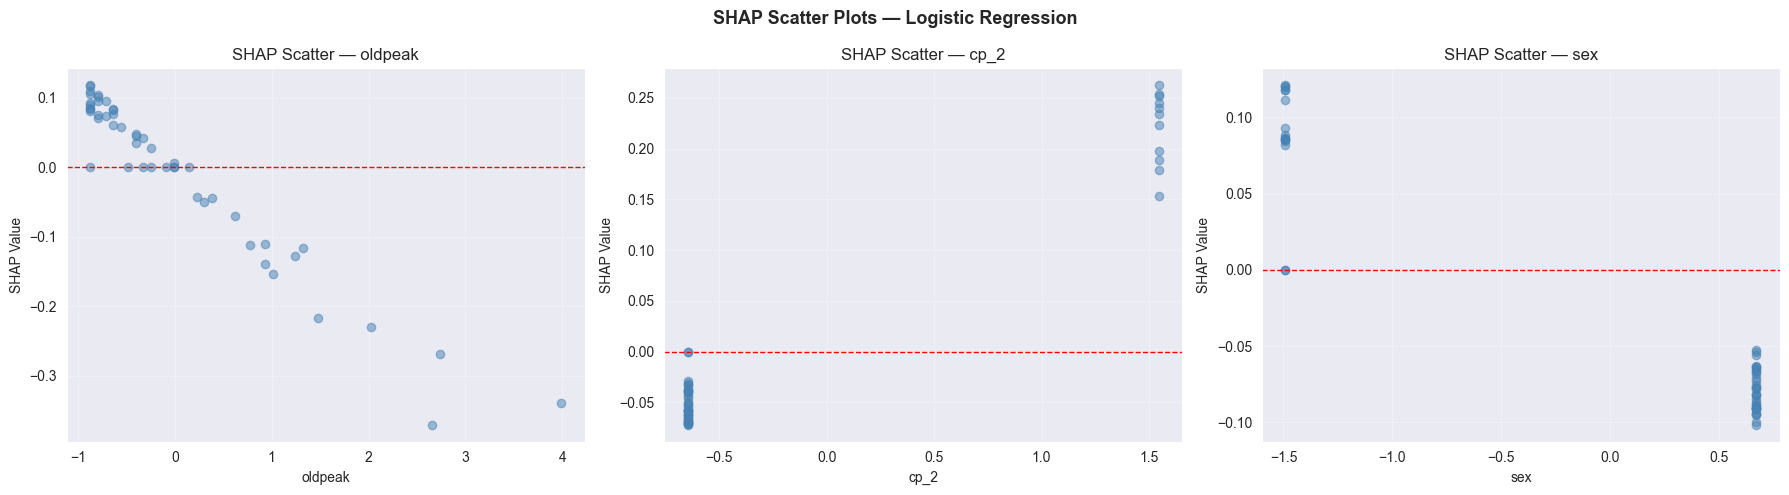

Top 3 most important features: ['oldpeak', 'cp_2', 'sex']

SHAP Analysis — CatBoost
SHAP values shape: (100, 15)
Features shape: (100, 15)


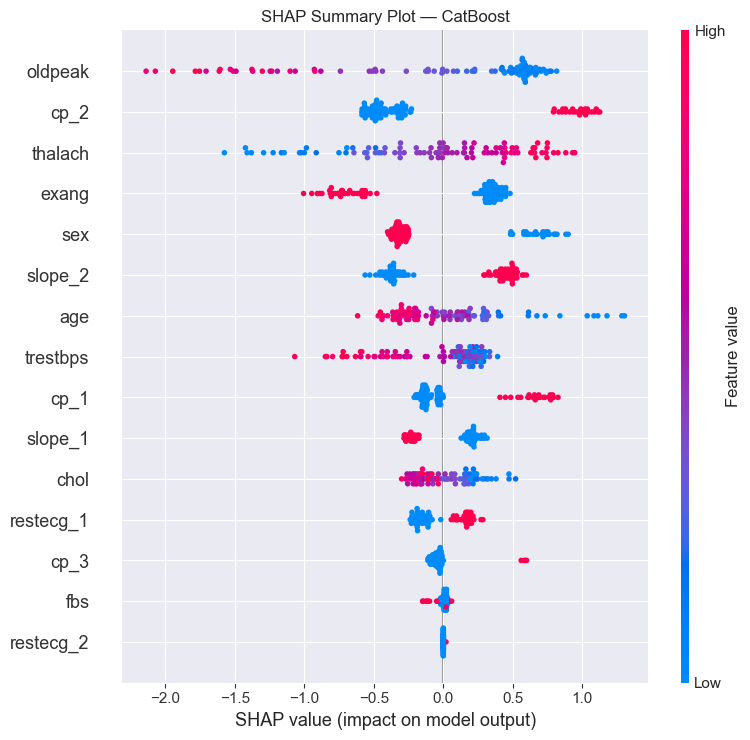

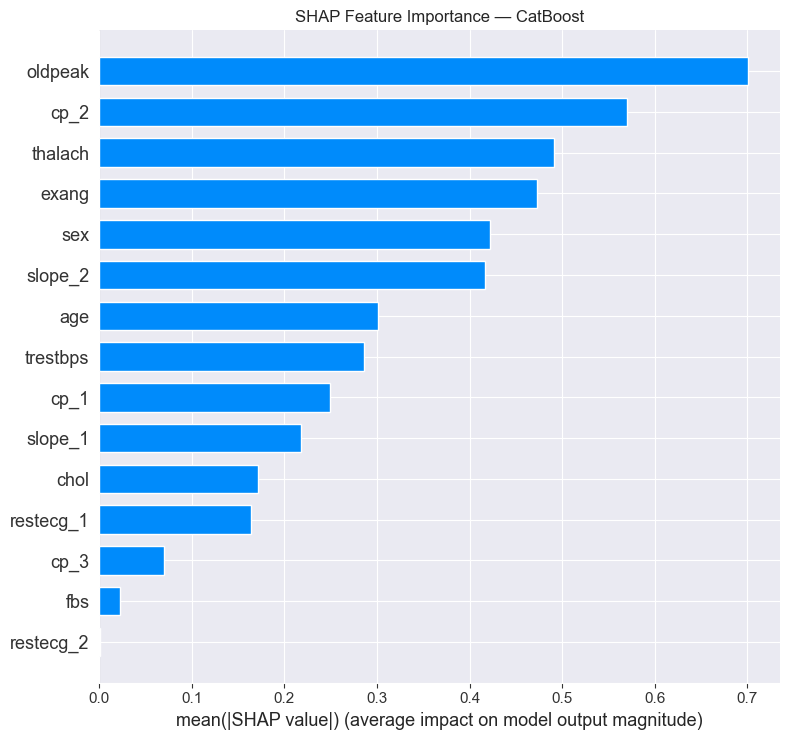

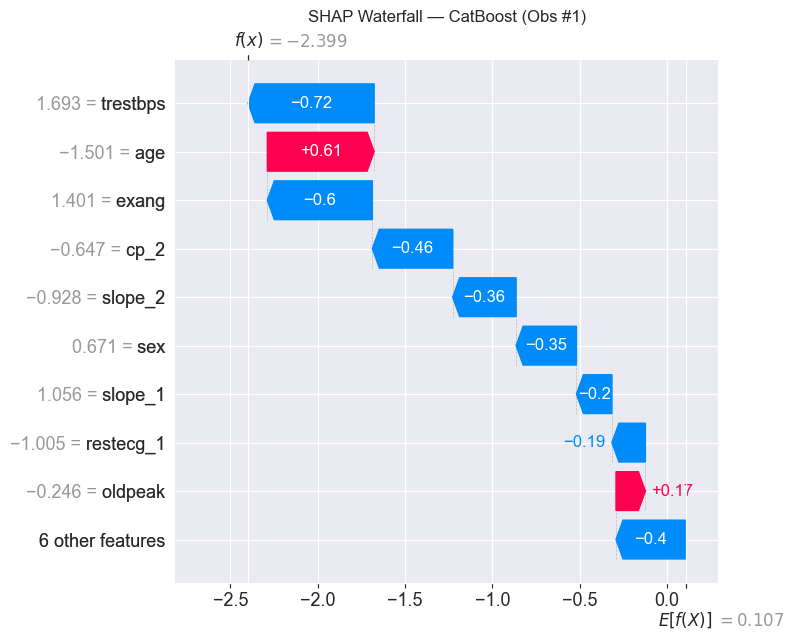

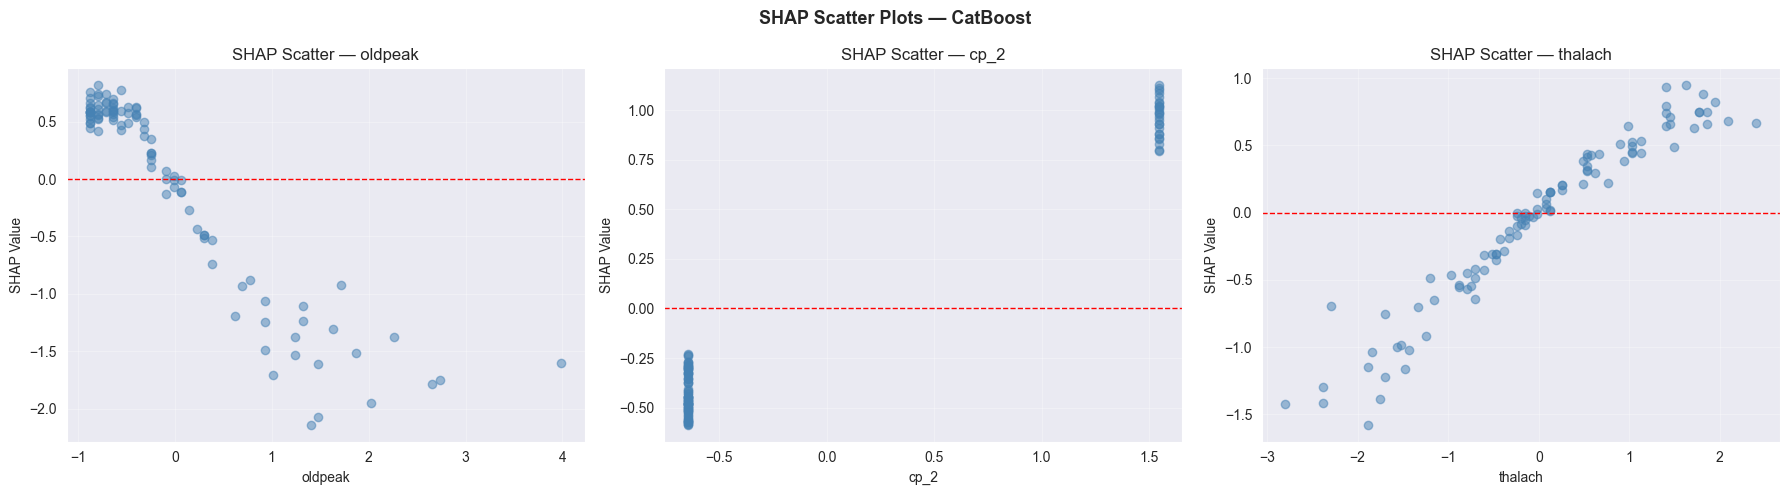

Top 3 most important features: ['oldpeak', 'cp_2', 'thalach']


In [8]:
top3_cls = list(optimized_models_cls.keys())[:3]

for model_name in top3_cls:
    model = optimized_models_cls[model_name]
    print(f'\n{"="*50}')
    print(f'SHAP Analysis — {model_name}')
    print(f'{"="*50}')

    n_samples = 100

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_cls_test[:n_samples])
        if isinstance(shap_values, list):
            sv = shap_values[1]
            ev = explainer.expected_value[1]
        else:
            sv = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
            ev = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
        X_used = X_cls_test[:n_samples]
    except Exception:
        background = shap.sample(pd.DataFrame(X_cls_train, columns=X_cls.columns), 50)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        n_samples_shap = 50
        shap_obj = explainer(pd.DataFrame(X_cls_test[:n_samples_shap], columns=X_cls.columns))
        sv = shap_obj.values[:, :, 1]
        ev = explainer.expected_value[1]
        X_used = X_cls_test[:n_samples_shap]

    X_test_df = pd.DataFrame(X_used, columns=X_cls.columns)

    print(f"SHAP values shape: {sv.shape}")
    print(f"Features shape: {X_test_df.shape}")

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test_df, show=False)
    plt.title(f'SHAP Summary Plot — {model_name}')
    plt.tight_layout()
    plt.show()

    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test_df, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance — {model_name}')
    plt.tight_layout()
    plt.show()

    # Waterfall plot
    exp = shap.Explanation(
        values=sv[0],
        base_values=ev,
        data=X_test_df.iloc[0].values,
        feature_names=X_cls.columns.tolist()
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, show=False)
    plt.title(f'SHAP Waterfall — {model_name} (Obs #1)')
    plt.tight_layout()
    plt.show()

    try:
        # Force plot
        shap.initjs()
        display(shap.force_plot(ev, sv[0], X_test_df.iloc[0], feature_names=X_cls.columns.tolist()))
    except Exception as e:
        print(f"Force plot error: {e}")

    # Scatter plots top 3 features
    mean_abs = np.abs(sv).mean(axis=0)
    top3_idx = np.argsort(mean_abs)[::-1][:3]
    top3_feat = X_cls.columns[top3_idx].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, idx in enumerate(top3_idx):
        axes[i].scatter(X_test_df.iloc[:, idx], sv[:, idx], alpha=0.5, color='steelblue')
        axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
        axes[i].set_xlabel(X_cls.columns[idx])
        axes[i].set_ylabel('SHAP Value')
        axes[i].set_title(f'SHAP Scatter — {X_cls.columns[idx]}')
        axes[i].grid(True, alpha=0.3)
    plt.suptitle(f'SHAP Scatter Plots — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Top 3 most important features: {top3_feat}')